In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Input
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt

In [3]:
(X_train, _), (X_test, _) = tf.keras.datasets.mnist.load_data()

In [4]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

In [7]:
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Compile the autoencoder
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [8]:
autoencoder.fit(X_train, X_train, epochs=5, batch_size=128, shuffle=True, validation_data=(X_test, X_test))

decoded_imgs = autoencoder.predict(X_test[:10])

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.2849 - val_loss: 0.1295
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.1248 - val_loss: 0.1126
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.1118 - val_loss: 0.1054
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.1057 - val_loss: 0.1016
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.1021 - val_loss: 0.0989
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step


In [9]:
encoder = Model(inputs=input_img, outputs=encoded)
encoded_imgs = encoder.predict(X_test)

original_shape = X_test[0].shape
compressed_shape = encoded_imgs[0].shape

print("Original image shape:", original_shape)
print("Compressed image shape:", compressed_shape)

original_size = np.prod(original_shape)
compressed_size = np.prod(compressed_shape)

print("Original image size (pixels):", original_size)
print("Compressed image size (pixels):", compressed_size)
print("Compression ratio: {:.2f}x".format(original_size / compressed_size))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Original image shape: (28, 28, 1)
Compressed image shape: (4, 4, 8)
Original image size (pixels): 784
Compressed image size (pixels): 128
Compression ratio: 6.12x


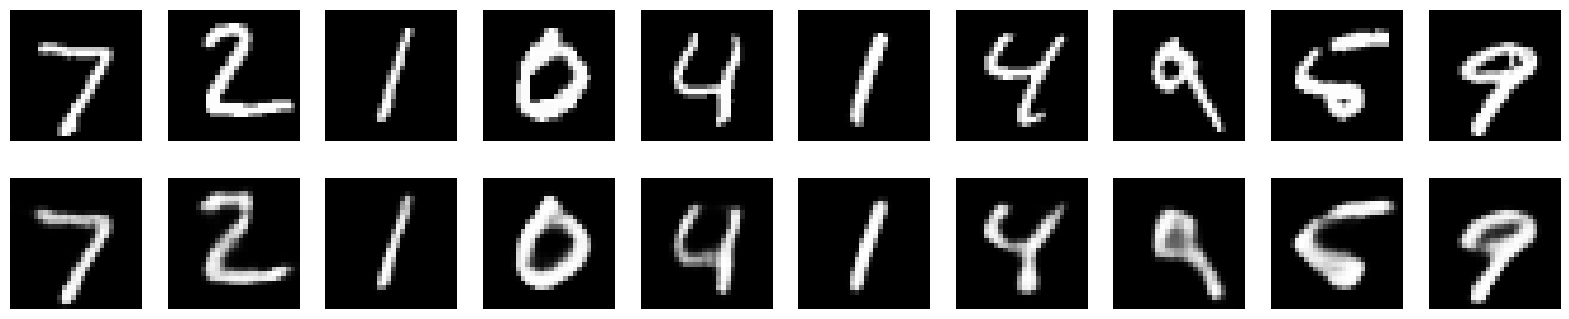

In [10]:
n = 10

plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.show()